# 久期计算结果验证分析

本notebook用于验证通过模型计算的基金久期与Wind披露的真实久期之间的差异。

In [1]:
from WindPy import w
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 启动Wind
w.start()
print("Wind连接成功")

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2024 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Wind连接成功


In [2]:
# 加载计算结果
result_df = pd.read_excel('./output/久期详细结果_exponential_20251231.xlsx')
result_df = result_df.rename(columns={'Unnamed: 0': 'fund_code'})

print(f"总基金数量: {len(result_df)}")
print(f"\n基金类型分布:")
print(result_df['fund_type'].value_counts())
print(f"\n债券类型分布:")
print(result_df['bond_type'].value_counts())

result_df.head()

总基金数量: 1564

基金类型分布:
fund_type
medium_long    1213
short           351
Name: count, dtype: int64

债券类型分布:
bond_type
credit    1212
rate       352
Name: count, dtype: int64


,fund_code,duration,fund_type,bond_type,name
0,000084.OF,0.078900,short,credit,博时安盈A
1,000089.OF,0.078900,short,credit,民生加银高等级信用债C
2,000128.OF,0.284118,short,credit,大成景安短融A
3,000322.OF,0.281549,short,credit,农银汇理金汇A
4,000394.OF,0.111112,short,credit,融通通源短融A


In [3]:
# 批量获取Wind披露的真实久期
def get_wind_duration_batch(fund_codes, rpt_date='20251231', batch_size=100):
    """
    批量获取Wind披露的基金久期
    
    参数:
        fund_codes: 基金代码列表
        rpt_date: 报告日期 'YYYYMMDD'
        batch_size: 每批获取的数量
    
    返回:
        dict: {fund_code: wind_duration}
    """
    wind_durations = {}
    total = len(fund_codes)
    
    for i in range(0, total, batch_size):
        batch = fund_codes[i:i+batch_size]
        print(f"处理进度: {i+1}-{min(i+batch_size, total)}/{total}")
        
        codes_str = ','.join(batch)
        try:
            data = w.wss(codes_str, "risk_durationupdate", f"rptDate={rpt_date}")
            if data.ErrorCode == 0:
                for j, code in enumerate(batch):
                    if j < len(data.Data[0]):
                        value = data.Data[0][j]
                        if value is not None and not (isinstance(value, float) and np.isnan(value)):
                            wind_durations[code] = float(value)
                        else:
                            wind_durations[code] = None
                    else:
                        wind_durations[code] = None
        except Exception as e:
            print(f"批次 {i+1}-{min(i+batch_size, total)} 出错: {e}")
            for code in batch:
                wind_durations[code] = None
    
    return wind_durations

# 获取所有基金的真实久期
fund_codes = result_df['fund_code'].tolist()
wind_durations = get_wind_duration_batch(fund_codes, rpt_date='20251231')

print(f"\n成功获取真实久期的基金数量: {sum(1 for v in wind_durations.values() if v is not None)}")

处理进度: 1-100/1564
处理进度: 101-200/1564
处理进度: 201-300/1564
处理进度: 301-400/1564
处理进度: 401-500/1564
处理进度: 501-600/1564
处理进度: 601-700/1564
处理进度: 701-800/1564
处理进度: 801-900/1564
处理进度: 901-1000/1564
处理进度: 1001-1100/1564
处理进度: 1101-1200/1564
处理进度: 1201-1300/1564
处理进度: 1301-1400/1564
处理进度: 1401-1500/1564
处理进度: 1501-1564/1564

成功获取真实久期的基金数量: 1552


In [4]:
# 合并数据
result_df['wind_duration'] = result_df['fund_code'].map(wind_durations)
result_df['duration_error'] = result_df['duration'] - result_df['wind_duration']
result_df['duration_pct_error'] = (result_df['duration_error'] / result_df['wind_duration']) * 100

# 移除Wind久期为空的记录
valid_df = result_df[result_df['wind_duration'].notna()].copy()

print(f"有效数据数量（有Wind真实久期）: {len(valid_df)}")
print(f"\n按类型统计:")
print(valid_df.groupby(['fund_type', 'bond_type']).size())

valid_df.head()

有效数据数量（有Wind真实久期）: 1552

按类型统计:
fund_type    bond_type
medium_long  credit       879
             rate         324
short        credit       322
             rate          27
dtype: int64


,fund_code,duration,fund_type,bond_type,name,wind_duration,duration_error,duration_pct_error
0,000084.OF,0.078900,short,credit,博时安盈A,0.534242,-0.455342,-85.231423
1,000089.OF,0.078900,short,credit,民生加银高等级信用债C,0.710841,-0.631941,-88.900476
2,000128.OF,0.284118,short,credit,大成景安短融A,1.051374,-0.767256,-72.976516
3,000322.OF,0.281549,short,credit,农银汇理金汇A,0.759769,-0.478220,-62.942819
4,000394.OF,0.111112,short,credit,融通通源短融A,0.103277,0.007835,7.586646


In [5]:
# 整体误差统计
print("=== 整体误差统计 ===")
print(f"平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
print(f"误差标准差: {valid_df['duration_error'].std():.4f} 年")
print(f"误差中位数: {valid_df['duration_error'].median():.4f} 年")
print(f"\n误差分布:")
print(valid_df['duration_error'].describe())

print(f"\n平均百分比误差: {valid_df['duration_pct_error'].mean():.2f}%")
print(f"百分比误差中位数: {valid_df['duration_pct_error'].median():.2f}%")

=== 整体误差统计 ===
平均绝对误差 (MAE): 1.2856 年
误差标准差: 1.5485 年
误差中位数: -0.8777 年

误差分布:
count    1552.000000
mean       -0.993590
std         1.548537
min       -12.879506
25%        -1.503959
50%        -0.877707
75%        -0.444849
max        11.693604
Name: duration_error, dtype: float64

平均百分比误差: -31.89%
百分比误差中位数: -47.74%


In [6]:
# 按类型分组统计
print("=== 按基金类型和债券类型统计 ===\n")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            
            print(f"{fund_type_name}{bond_type_name} (n={len(subset)}):")
            print(f"  平均绝对误差: {subset['duration_error'].abs().mean():.4f} 年")
            print(f"  误差标准差: {subset['duration_error'].std():.4f} 年")
            print(f"  平均计算久期: {subset['duration'].mean():.4f} 年")
            print(f"  平均Wind久期: {subset['wind_duration'].mean():.4f} 年")
            print()

=== 按基金类型和债券类型统计 ===

短期信用债 (n=322):
  平均绝对误差: 0.8135 年
  误差标准差: 0.6160 年
  平均计算久期: 0.3889 年
  平均Wind久期: 1.1253 年

短期利率债 (n=27):
  平均绝对误差: 0.5007 年
  误差标准差: 0.5862 年
  平均计算久期: 1.1513 年
  平均Wind久期: 1.4061 年

中长期信用债 (n=879):
  平均绝对误差: 1.1473 年
  误差标准差: 1.4365 年
  平均计算久期: 1.6283 年
  平均Wind久期: 2.4206 年

中长期利率债 (n=324):
  平均绝对误差: 2.1955 年
  误差标准差: 2.1286 年
  平均计算久期: 2.2233 年
  平均Wind久期: 4.0802 年



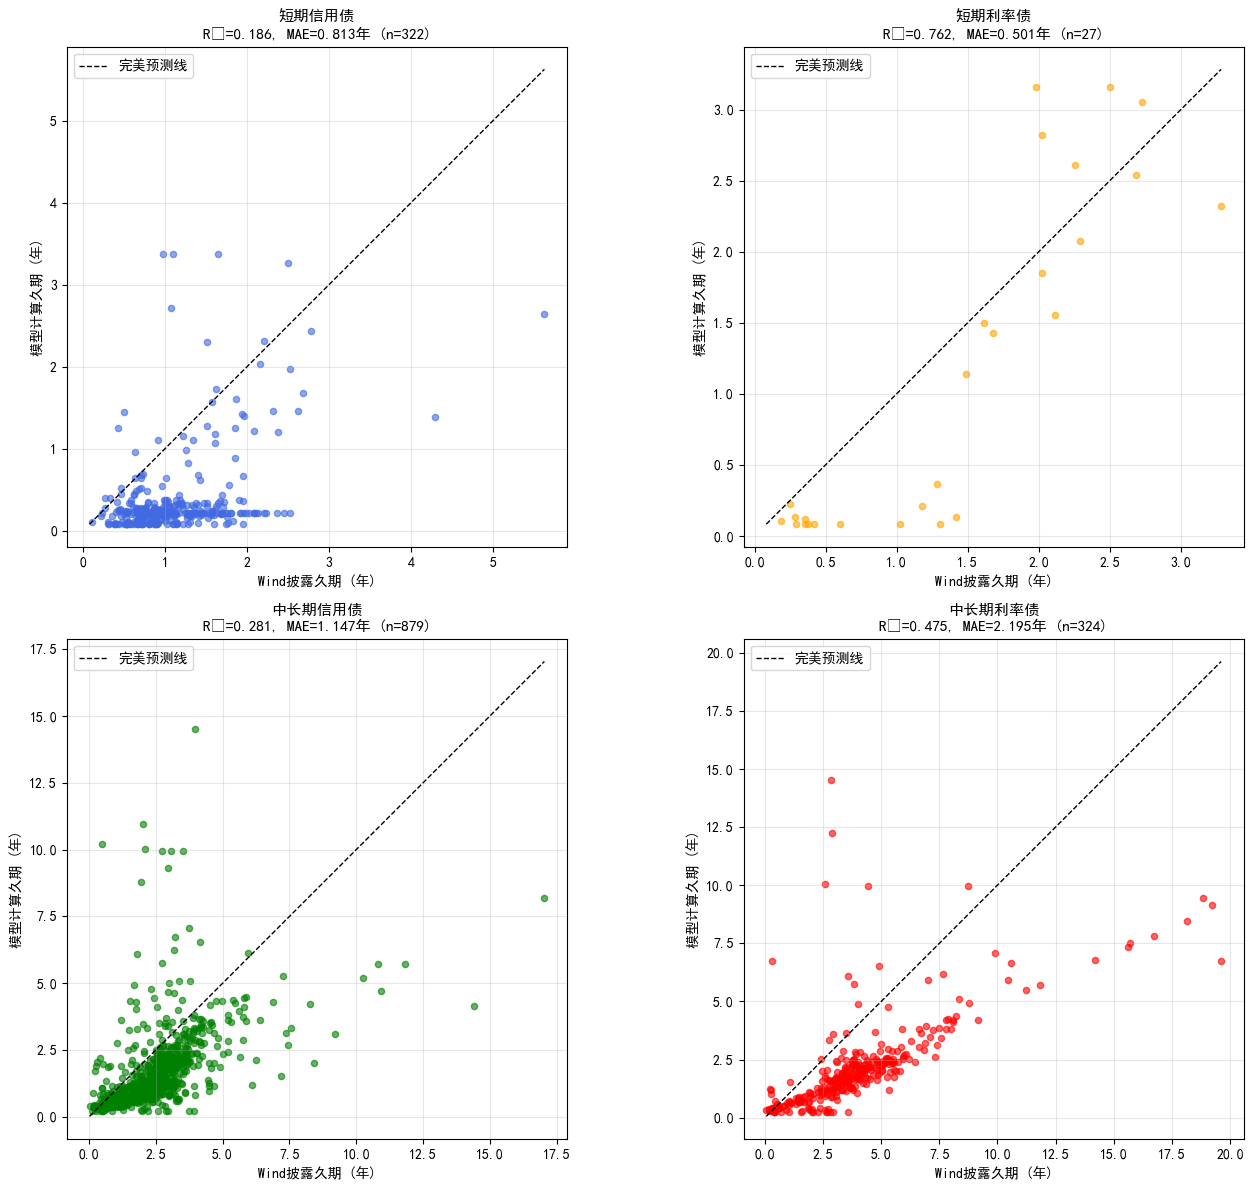

散点图已保存为: ./output/久期验证散点图.png


In [7]:
# 绘制散点图对比
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 定义类型映射
type_map = {
    ('short', 'credit'): ('短期信用债', 'royalblue'),
    ('short', 'rate'): ('短期利率债', 'orange'),
    ('medium_long', 'credit'): ('中长期信用债', 'green'),
    ('medium_long', 'rate'): ('中长期利率债', 'red')
}

for idx, ((fund_type, bond_type), (type_name, color)) in enumerate(type_map.items()):
    ax = axes[idx // 2, idx % 2]
    
    mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
    subset = valid_df[mask]
    
    if len(subset) > 0:
        # 散点图
        ax.scatter(subset['wind_duration'], subset['duration'], alpha=0.6, color=color, s=20)
        
        # 45度线（完美预测线）
        min_val = min(subset['wind_duration'].min(), subset['duration'].min())
        max_val = max(subset['wind_duration'].max(), subset['duration'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, label='完美预测线')
        
        # 计算R²
        correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0, 1]
        r_squared = correlation ** 2
        mae = subset['duration_error'].abs().mean()
        
        ax.set_xlabel('Wind披露久期 (年)', fontsize=10)
        ax.set_ylabel('模型计算久期 (年)', fontsize=10)
        ax.set_title(f'{type_name}\nR²={r_squared:.3f}, MAE={mae:.3f}年 (n={len(subset)})', fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('./output/久期验证散点图.png', dpi=150, bbox_inches='tight')
plt.show()
print("散点图已保存为: ./output/久期验证散点图.png")

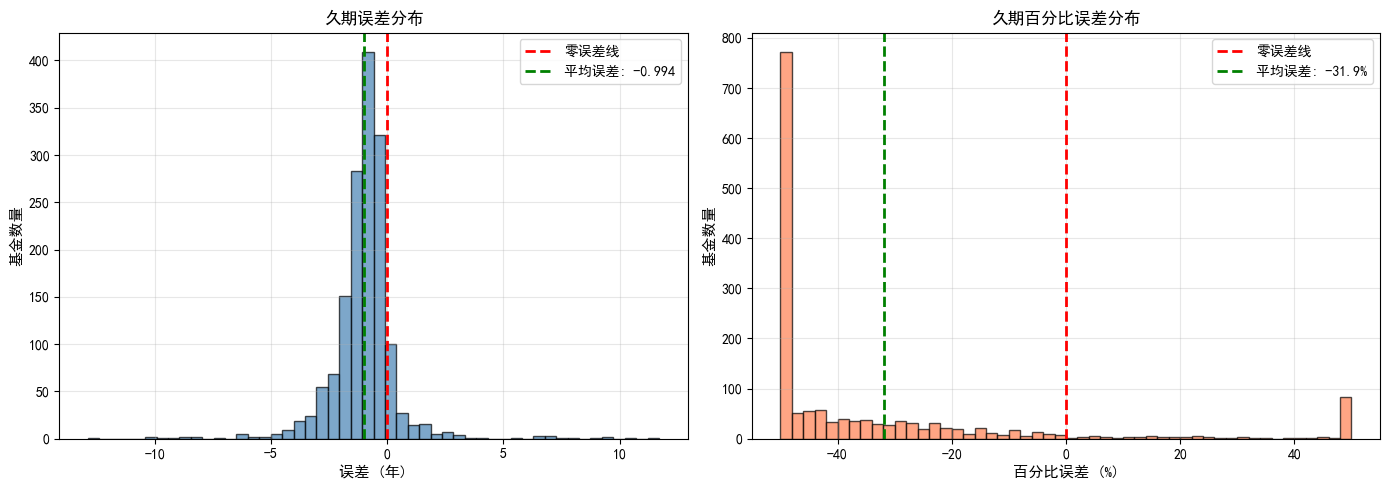

误差分布图已保存为: 误差分布图.png


In [8]:
# 误差分布直方图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绝对误差分布
axes[0].hist(valid_df['duration_error'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[0].axvline(valid_df['duration_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_error"].mean():.3f}')
axes[0].set_xlabel('误差 (年)', fontsize=11)
axes[0].set_ylabel('基金数量', fontsize=11)
axes[0].set_title('久期误差分布', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 百分比误差分布（限制在±50%以内以便观察）
pct_error_limited = valid_df['duration_pct_error'].clip(-50, 50)
axes[1].hist(pct_error_limited, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2, label='零误差线')
axes[1].axvline(valid_df['duration_pct_error'].mean(), color='green', linestyle='--', lw=2, label=f'平均误差: {valid_df["duration_pct_error"].mean():.1f}%')
axes[1].set_xlabel('百分比误差 (%)', fontsize=11)
axes[1].set_ylabel('基金数量', fontsize=11)
axes[1].set_title('久期百分比误差分布', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./output/误差分布图.png', dpi=150, bbox_inches='tight')
plt.show()
print("误差分布图已保存为: 误差分布图.png")

In [9]:
# 找出误差最大的基金（可能有问题或需要特殊处理）
print("=== 绝对误差最大的20只基金 ===")
# 先创建绝对误差列
valid_df['duration_error_abs'] = valid_df['duration_error'].abs()
top_errors = valid_df.nlargest(20, 'duration_error_abs')[['fund_code', 'name', 'duration', 'wind_duration', 'duration_error', 'duration_pct_error', 'fund_type', 'bond_type']]
print(top_errors.to_string(index=False))

# 保存到Excel
valid_df.to_excel('./output/久期验证完整结果_20251231.xlsx', index=False)
print(f"\n完整验证结果已保存为: 久期验证完整结果_20251231.xlsx")

=== 绝对误差最大的20只基金 ===
fund_code            name  duration  wind_duration  duration_error  duration_pct_error   fund_type bond_type
016016.OF        长盛恒盛利率债A  6.742074      19.621580      -12.879506          -65.639493 medium_long      rate
020204.OF     路博迈中国精选利率债A 14.513580       2.819976       11.693604          414.670249 medium_long      rate
006367.OF         交银裕祥纯债A 14.513580       3.949472       10.564108          267.481558 medium_long    credit
006764.OF     景顺长城景泰鑫利纯债A  4.164836      14.411525      -10.246689          -71.100657 medium_long    credit
017459.OF        汇添富丰和纯债A  9.131952      19.219018      -10.087066          -52.484815 medium_long      rate
002811.OF         博时裕顺纯债A 10.206748       0.495858        9.710890         1958.402303 medium_long    credit
020327.OF 华泰保兴尊益利率债6个月持有A  8.474974      18.136936       -9.661961          -53.272291 medium_long      rate
015433.OF          金元顺安泓泽  9.430819      18.855506       -9.424687          -49.983738 medium_long      rat

In [10]:
# 生成验证报告摘要
summary = []
summary.append("="*60)
summary.append("久期计算验证报告摘要")
summary.append("="*60)
summary.append(f"验证日期: 2025-12-31")
summary.append(f"总计算基金数: {len(result_df)}")
summary.append(f"有效验证数（有Wind真实久期）: {len(valid_df)}")
summary.append("")
summary.append("整体误差统计:")
summary.append(f"  - 平均绝对误差 (MAE): {valid_df['duration_error'].abs().mean():.4f} 年")
summary.append(f"  - 误差标准差: {valid_df['duration_error'].std():.4f} 年")
summary.append(f"  - 相关系数: {np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1]:.4f}")
summary.append(f"  - R²: {(np.corrcoef(valid_df['wind_duration'], valid_df['duration'])[0,1])**2:.4f}")
summary.append("")
summary.append("按类型统计:")

for fund_type in ['short', 'medium_long']:
    for bond_type in ['credit', 'rate']:
        mask = (valid_df['fund_type'] == fund_type) & (valid_df['bond_type'] == bond_type)
        subset = valid_df[mask]
        
        if len(subset) > 0:
            fund_type_name = '短期' if fund_type == 'short' else '中长期'
            bond_type_name = '信用债' if bond_type == 'credit' else '利率债'
            correlation = np.corrcoef(subset['wind_duration'], subset['duration'])[0,1]
            
            summary.append(f"  {fund_type_name}{bond_type_name} (n={len(subset)}):")
            summary.append(f"    MAE: {subset['duration_error'].abs().mean():.4f}年, R²: {correlation**2:.4f}")

summary.append("="*60)

# 打印报告
print("\n".join(summary))

# 保存报告
with open('./output/验证报告.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(summary))
print("\n验证报告已保存为: ./output/验证报告.txt")

久期计算验证报告摘要
验证日期: 2025-12-31
总计算基金数: 1564
有效验证数（有Wind真实久期）: 1552

整体误差统计:
  - 平均绝对误差 (MAE): 1.2856 年
  - 误差标准差: 1.5485 年
  - 相关系数: 0.6578
  - R²: 0.4327

按类型统计:
  短期信用债 (n=322):
    MAE: 0.8135年, R²: 0.1864
  短期利率债 (n=27):
    MAE: 0.5007年, R²: 0.7624
  中长期信用债 (n=879):
    MAE: 1.1473年, R²: 0.2813
  中长期利率债 (n=324):
    MAE: 2.1955年, R²: 0.4755

验证报告已保存为: ./output/验证报告.txt
